In [ ]:
#!/usr/bin/env python3
"""
End-to-end training script for blind array-calibration
(Ψ gains and Φ phases) from sample-covariance matrices.

• Loads the NPZ dataset whose path you give in TRAIN_PATH (used for train/val/test split).
• Infers the array size M automatically from the TRAIN_PATH file.
• Builds a lightweight CNN → dense head that outputs 2M values.
• Trains with an 80 / 10 / 10 split, shows RMSE per epoch.
• Saves the trained weights as calibnet_M<whatever>.pt
• Optionally evaluates on an external TEST_PATH NPZ (e.g., high-SNR test set with BCRB).
"""

# -------------------------------------------------
# 0)  Imports
# -------------------------------------------------
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, random_split
from pathlib import Path
from tqdm import tqdm

# -------------------------------------------------
# 1)  File locations & basic hyper-params
# -------------------------------------------------
# Set your dataset directory and files here:
BASE_DIR  = Path("/home/apanchagatti/amogh_calibration/Datasets")
TRAIN_PATH = BASE_DIR / "train_high_snr.npz"        # used for train/val/test split
TEST_PATH  = BASE_DIR / "test_high_snr_bcrb.npz"    # optional external evaluation

# Training parameters
BATCH       = 64
LR          = 1e-3
EPOCHS      = 500
VAL_FRAC    = 0.10
TEST_FRAC   = 0.10
DEVICE      = "cuda" if torch.cuda.is_available() else "cpu"
TORCH_SEED  = 0          # reproducible splits / init

# -------------------------------------------------
# 2)  Peek at TRAIN_PATH to discover M
# -------------------------------------------------
assert TRAIN_PATH.exists(), f"TRAIN_PATH not found: {TRAIN_PATH}"
with np.load(TRAIN_PATH) as npz:
    n, ch, M, _ = npz["X"].shape
    assert ch == 2, "Expected 2-channel (real/imag) input"
print(f"[INFO] Using TRAIN_PATH = {TRAIN_PATH}")
print(f"[INFO] Detected dataset with N = {n} samples, array size M = {M}")

# -------------------------------------------------
# 3)  PyTorch Dataset wrapper
# -------------------------------------------------
class CovDataset(Dataset):
    def __init__(self, npz_path: Path):
        data = np.load(npz_path)
        self.X = torch.from_numpy(data["X"]).float()  # (N, 2, M, M)
        self.y = torch.from_numpy(data["y"]).float()  # (N, 2M)

    def __len__(self):
        return self.X.shape[0]

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

torch.manual_seed(TORCH_SEED)
full_ds = CovDataset(TRAIN_PATH)

N = len(full_ds)
n_val   = int(VAL_FRAC  * N)
n_test  = int(TEST_FRAC * N)
n_train = N - n_val - n_test
train_ds, val_ds, test_ds = random_split(
    full_ds, [n_train, n_val, n_test],
    generator=torch.Generator().manual_seed(TORCH_SEED)
)

train_loader = DataLoader(train_ds, BATCH, shuffle=True)
val_loader   = DataLoader(val_ds,   BATCH, shuffle=False)
test_loader  = DataLoader(test_ds,  BATCH, shuffle=False)

# -------------------------------------------------
# 4)  Model definition
# -------------------------------------------------
class CalibNet(nn.Module):
    """
    CalibNet with dropout:
      - Dropout in the head (default p=0.30) is the main regularizer.
      - Optional Dropout2d in the conv stack (default p=0.0; set to 0.1–0.3 if needed).
    Inputs:
      x: (B, 2, H, W) e.g., stacked [Re, Im] or [mag, phase]
    Outputs:
      concat([psi_hat, phi_hat]) with shapes (B, M) + (B, M)
    """
    def __init__(self, M, p_drop_head: float = 0.30, p_drop_conv: float = 0.0):
        super().__init__()
        self.M = M

        # Optional spatial dropout between conv blocks
        Drop2d = nn.Dropout2d if p_drop_conv > 0 else (lambda p: nn.Identity())

        self.cnn = nn.Sequential(
            nn.Conv2d(2, 32, 3, padding=1), nn.ReLU(inplace=True),
            nn.Conv2d(32, 64, 3, padding=1), nn.ReLU(inplace=True),
            Drop2d(p_drop_conv),                         # e.g., 0.1–0.2 if needed
            nn.Conv2d(64, 64, 3, padding=1), nn.ReLU(inplace=True),
            nn.AdaptiveAvgPool2d(1),                    # (B, 64, 1, 1)
            nn.Flatten()                                # (B, 64)
        )

        self.head = nn.Sequential(
            nn.Linear(64, 128), nn.ReLU(inplace=True),
            nn.Dropout(p=p_drop_head),                  # main dropout (try 0.3 first)
            nn.Linear(128, 2*M)
        )

        self.softplus = nn.Softplus(beta=1.5)          # gains >= 0

    def forward(self, x):
        z = self.cnn(x)                                # (B, 64)
        out = self.head(z)                             # (B, 2M)
        psi_raw, phi_raw = out[:, :self.M], out[:, self.M:]
        psi_hat = self.softplus(psi_raw)               # Ψ ∈ [0, ∞)
        phi_hat = torch.tanh(phi_raw) * math.pi        # Φ ∈ (−π, π)
        return torch.cat([psi_hat, phi_hat], dim=1)    # (B, 2M)
M = 8  # example
model = CalibNet(M, p_drop_head=0.30, p_drop_conv=0.0).to(DEVICE)
opt  = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=1e-4)
crit = nn.MSELoss()
# -------------------------------------------------
# 5)  Helper to run one epoch
# -------------------------------------------------
def run_epoch(loader, training=False):
    model.train(training)
    total_mse = 0.0
    with torch.set_grad_enabled(training):
        for X, y in loader:
            X, y = X.to(DEVICE), y.to(DEVICE)
            if training:
                opt.zero_grad()
            y_hat = model(X)
            loss  = crit(y_hat, y)
            if training:
                loss.backward()
                opt.step()
            total_mse += loss.item() * X.size(0)
    rmse = np.sqrt(total_mse / len(loader.dataset))
    return rmse

# -------------------------------------------------
# 6)  Training loop
# -------------------------------------------------
best_val = float("inf")
best_ckpt_path = Path(f"calibnet_M{M}.pt")
for epoch in range(1, EPOCHS+1):
    train_rmse = run_epoch(train_loader, training=True)
    val_rmse   = run_epoch(val_loader,   training=False)

    if val_rmse < best_val:
        best_val = val_rmse
        torch.save(model.state_dict(), best_ckpt_path)

    print(f"Epoch {epoch:02d}/{EPOCHS}  "
          f"train RMSE {train_rmse:.4f}  val RMSE {val_rmse:.4f}")

# -------------------------------------------------
# 7)  Final internal test evaluation (split from TRAIN_PATH)
# -------------------------------------------------
model.load_state_dict(torch.load(best_ckpt_path, map_location=DEVICE))
test_rmse = run_epoch(test_loader, training=False)
print(f"\n[RESULT] Best model internal test RMSE = {test_rmse:.4f}")
print(f"[INFO]   Model weights saved to {best_ckpt_path.resolve()}")

# -------------------------------------------------
# 8)  Evaluate on external test set (TEST_PATH), if available
# -------------------------------------------------
if TEST_PATH.exists():
    external_test = CovDataset(TEST_PATH)
    ext_loader = DataLoader(external_test, BATCH, shuffle=False)
    ext_rmse = run_epoch(ext_loader, training=False)
    print(f"[RESULT] External test RMSE ({TEST_PATH.name}) = {ext_rmse:.4f}")
else:
    print(f"[WARN]   TEST_PATH not found: {TEST_PATH}")


[INFO] Using TRAIN_PATH = /home/apanchagatti/amogh_calibration/Datasets/train_high_snr.npz
[INFO] Detected dataset with N = 40000 samples, array size M = 6
Epoch 01/500  train RMSE 0.5113  val RMSE 0.3943
Epoch 02/500  train RMSE 0.3627  val RMSE 0.3434
Epoch 03/500  train RMSE 0.3269  val RMSE 0.3128
Epoch 04/500  train RMSE 0.3053  val RMSE 0.3022
Epoch 05/500  train RMSE 0.2885  val RMSE 0.2813
Epoch 06/500  train RMSE 0.2742  val RMSE 0.2698
Epoch 07/500  train RMSE 0.2608  val RMSE 0.2654
Epoch 08/500  train RMSE 0.2500  val RMSE 0.2514
Epoch 09/500  train RMSE 0.2405  val RMSE 0.2489
Epoch 10/500  train RMSE 0.2307  val RMSE 0.2383
Epoch 11/500  train RMSE 0.2241  val RMSE 0.2321
Epoch 12/500  train RMSE 0.2168  val RMSE 0.2371
Epoch 13/500  train RMSE 0.2093  val RMSE 0.2234
Epoch 14/500  train RMSE 0.2039  val RMSE 0.2191
Epoch 15/500  train RMSE 0.1996  val RMSE 0.2159
Epoch 16/500  train RMSE 0.1959  val RMSE 0.2207
Epoch 17/500  train RMSE 0.1909  val RMSE 0.2215
Epoch 18/50

KeyboardInterrupt: 

In [20]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict
from pathlib import Path
device= "cuda" if torch.cuda.is_available() else "cpu"

def evaluate_model_vs_bcrb(model, npz_path, device="cuda"):
    device= "cuda" if torch.cuda.is_available() else "cpu"
    npz_path = Path(npz_path)
    with np.load(npz_path) as data:
        X = torch.from_numpy(data["X"]).float().to(device)
        y = torch.from_numpy(data["y"]).float().to(device)
        snr = data["snr_db"]
        bcrb_g = data["bcrb_gain"]
        bcrb_p = data["bcrb_phase"]

    model.eval()
    with torch.no_grad():
        y_hat = model(X).cpu().numpy()
    y_true = y.cpu().numpy()

    # Compute empirical MSEs
    err = (y_hat - y_true) ** 2
    M = err.shape[1] // 2
    mse_gain  = err[:, :M].mean(axis=1)
    mse_phase = err[:, M:].mean(axis=1)

    # Group by SNR
    by_snr_mse_g, by_snr_mse_p = defaultdict(list), defaultdict(list)
    by_snr_bcrb_g, by_snr_bcrb_p = defaultdict(list), defaultdict(list)
    for s, mg, mp, bg, bp in zip(snr, mse_gain, mse_phase, bcrb_g.mean(axis=1), bcrb_p.mean(axis=1)):
        by_snr_mse_g[int(s)].append(mg)
        by_snr_mse_p[int(s)].append(mp)
        by_snr_bcrb_g[int(s)].append(bg)
        by_snr_bcrb_p[int(s)].append(bp)

    snr_levels = sorted(by_snr_mse_g.keys())
    mean_mse_g = [np.mean(by_snr_mse_g[s]) for s in snr_levels]
    mean_mse_p = [np.mean(by_snr_mse_p[s]) for s in snr_levels]
    mean_bcrb_g = [np.mean(by_snr_bcrb_g[s]) for s in snr_levels]
    mean_bcrb_p = [np.mean(by_snr_bcrb_p[s]) for s in snr_levels]

    # --- Plot gains ---
    plt.figure()
    plt.plot(snr_levels, mean_bcrb_g, 'k--', label='BCRB (gain Ψ)')
    plt.plot(snr_levels, mean_mse_g, 'r-o', label='Network MSE (gain Ψ)')
    plt.yscale('log')
    plt.xlabel('SNR (dB)')
    plt.ylabel('Mean Squared Error (gain)')
    plt.title('Gain Estimation vs BCRB')
    plt.legend()
    plt.grid(True, which='both', ls='--', alpha=0.4)
    plt.tight_layout()

    # --- Plot phases ---
    plt.figure()
    plt.plot(snr_levels, mean_bcrb_p, 'k--', label='BCRB (phase Φ)')
    plt.plot(snr_levels, mean_mse_p, 'b-o', label='Network MSE (phase Φ)')
    plt.yscale('log')
    plt.xlabel('SNR (dB)')
    plt.ylabel('Mean Squared Error (phase)')
    plt.title('Phase Estimation vs BCRB')
    plt.legend()
    plt.grid(True, which='both', ls='--', alpha=0.4)
    plt.tight_layout()
    plt.show()


/tmp/ipykernel_1424105/2192909174.py:1: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load("calibnet_M6.pt"))


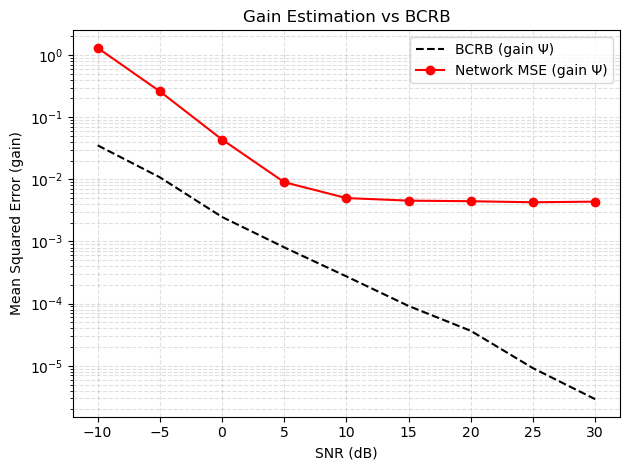

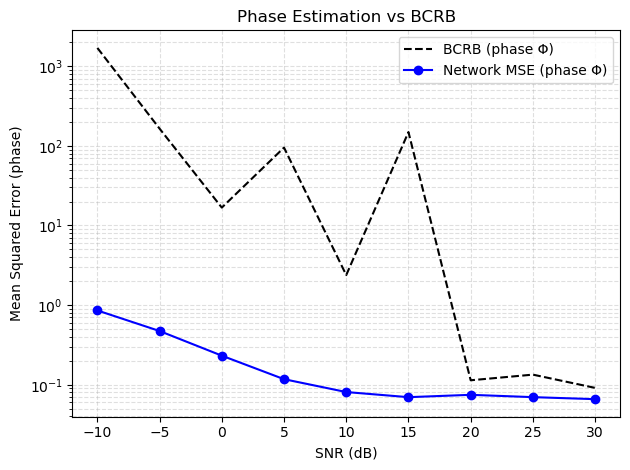

In [21]:
model.load_state_dict(torch.load("calibnet_M6.pt"))
evaluate_model_vs_bcrb(model,"Datasets/test_high_snr_bcrb.npz")


In [13]:
npz_path = Path('datasets/test_balanced_bcrb.npz')

In [14]:
npz_path

PosixPath('datasets/test_balanced_bcrb.npz')